# Отчёт по эксперименту Target24: GRPO-only vs SFT→GRPO vs SRFT

Этот ноутбук собран **по данным из твоего ноутбука** `GRPO_full_experiment (4).ipynb`.  
Сюда перенесены:
- краткое описание трёх методов,
- конфигурация эксперимента,
- таблицы метрик,
- графики из ноутбука,
- примеры решённых и нерешённых задач,
- интерпретация результатов и выводы для отчёта.

Ноутбук оформлен как цельный репорт, чтобы его можно было открыть, показать и при необходимости быстро отредактировать прямо в markdown-ячейках.


## 1. Что сравнивалось

В работе сравнивались три подхода:

1. **GRPO-only** — обучение только по reward с curriculum learning и mixing предыдущих уровней.
2. **SFT→GRPO** — сначала supervised fine-tuning на gold trajectories, затем тот же GRPO curriculum.
3. **SRFT** — single-stage SRFT-подобная схема по мотивам статьи 2506.19767.


## 2. Конфигурация, восстановленная из кода

- Базовая модель: `Qwen2.5-0.5B-Instruct`
- Адаптация: LoRA, `rank=16`, 4-bit загрузка
- Максимальная длина последовательности: `512`
- Оценка: `pass@k` на validation, `128` сэмплов на задачу
- Генерация на train для GRPO/SRFT: `num_generations=2`
- `max_completion_length=96`
- Для SFT использовался `sft_gold.jsonl`, один проход по датасету
- Для SRFT использовались:
  - `demo_batch_size=2`
  - `rollout_batch_size=1`
  - `num_generations=2`
  - шаги по уровню: примерно половина от GRPO curriculum, но не меньше 80


## 3. Главные результаты

### Сводка по средним метрикам

| Метод | Средний pass@1 | Средний pass@128 | Ключевое наблюдение |
|---|---|---|---|
| GRPO-only | 0.0839 | 0.0859 | Учит простые уровни, но почти не переносится на сложные; p@1≈p@128. |
| SFT→GRPO | 0.1805 | 0.3661 | Лучший метод почти на всех уровнях, особенно на L8–L10. |
| SRFT | 0.0030 | 0.1659 | На лёгких уровнях иногда находит решение среди 128 сэмплов, но one-shot качество почти нулевое. |

### Подробные метрики по уровням

| Level | GRPO pass@1 | GRPO pass@128 | SFT→GRPO pass@1 | SFT→GRPO pass@128 | SRFT pass@1 | SRFT pass@128 |
|---|---|---|---|---|---|---|
| L1 | 0.1786 | 0.1786 | 0.6364 | 0.8214 | 0.0187 | 0.6786 |
| L2 | 0.0800 | 0.0800 | 0.3336 | 0.4800 | 0.0048 | 0.3200 |
| L3 | 0.2556 | 0.2600 | 0.2967 | 0.3800 | 0.0030 | 0.2800 |
| L4 | 0.0800 | 0.0800 | 0.1847 | 0.4000 | 0.0006 | 0.0600 |
| L5 | 0.1352 | 0.1400 | 0.0880 | 0.2000 | 0.0028 | 0.2600 |
| L6 | 0.0578 | 0.0600 | 0.1166 | 0.3800 | 0.0003 | 0.0400 |
| L7 | 0.0333 | 0.0400 | 0.0508 | 0.2800 | 0.0000 | 0.0000 |
| L8 | 0.0181 | 0.0200 | 0.0669 | 0.3400 | 0.0000 | 0.0000 |
| L9 | 0.0000 | 0.0000 | 0.0266 | 0.3200 | 0.0002 | 0.0200 |
| L10 | 0.0000 | 0.0000 | 0.0050 | 0.0600 | 0.0000 | 0.0000 |

## 4. Графики из ноутбука

Ниже собраны основные фигуры, которые можно использовать прямо в отчёте.


### GRPO-only: reward curves

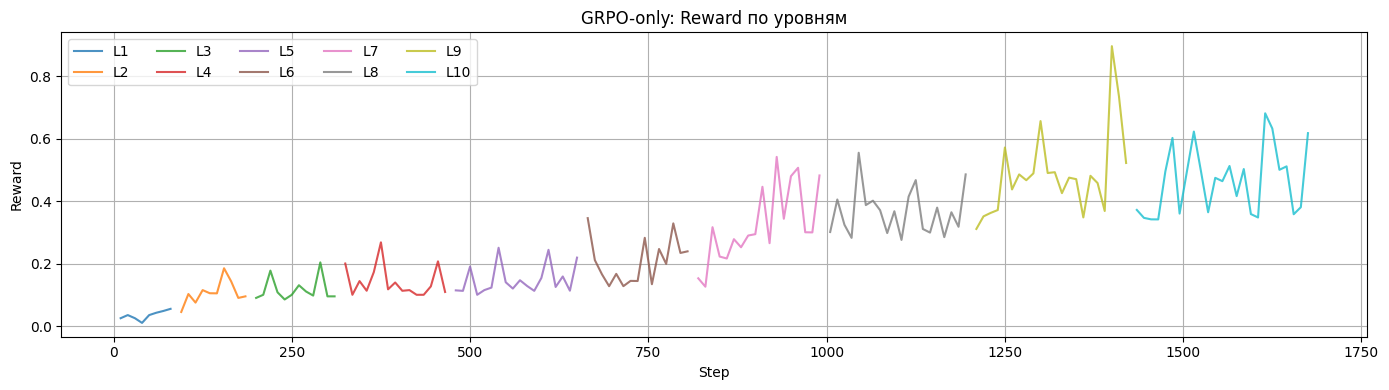

На этих кривых видно, что reward у GRPO-only растёт на части уровней, но это не приводит к сильному переносу на сложные задачи.

### GRPO-only: pass@1 vs pass@128

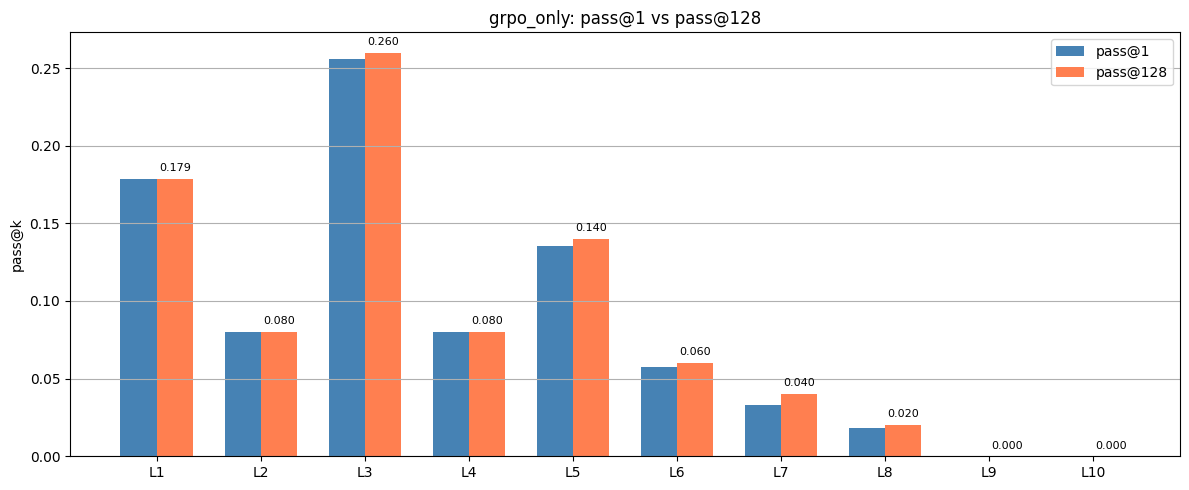

Для GRPO-only `pass@1` и `pass@128` почти совпадают. Это означает, что модель либо уже выучила паттерн и решает его сразу, либо не умеет его решать вообще.

### SFT→GRPO: SFT loss, reward curves и pass@k

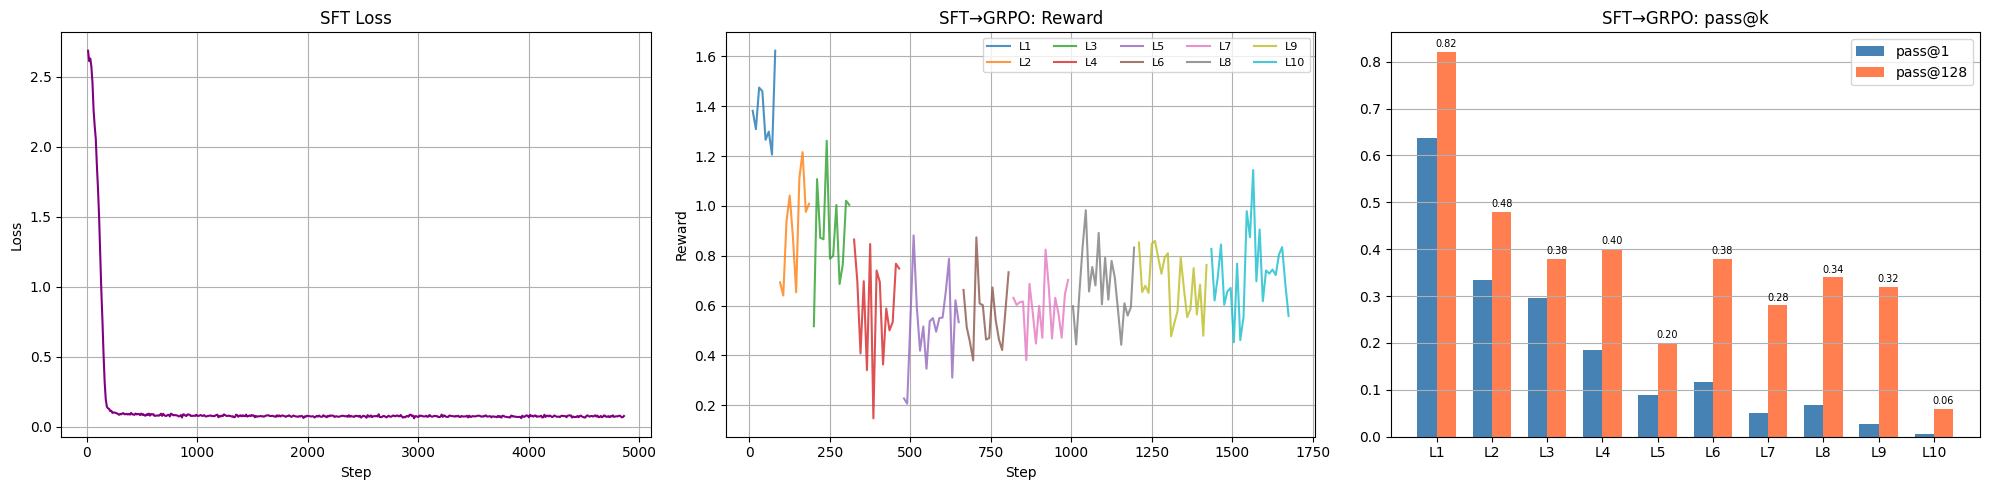

Это самая сильная схема в эксперименте: supervised этап даёт хорошую инициализацию, а последующий GRPO помогает дожать качество по reward.

### SRFT: training losses, reward curves и validation pass@k

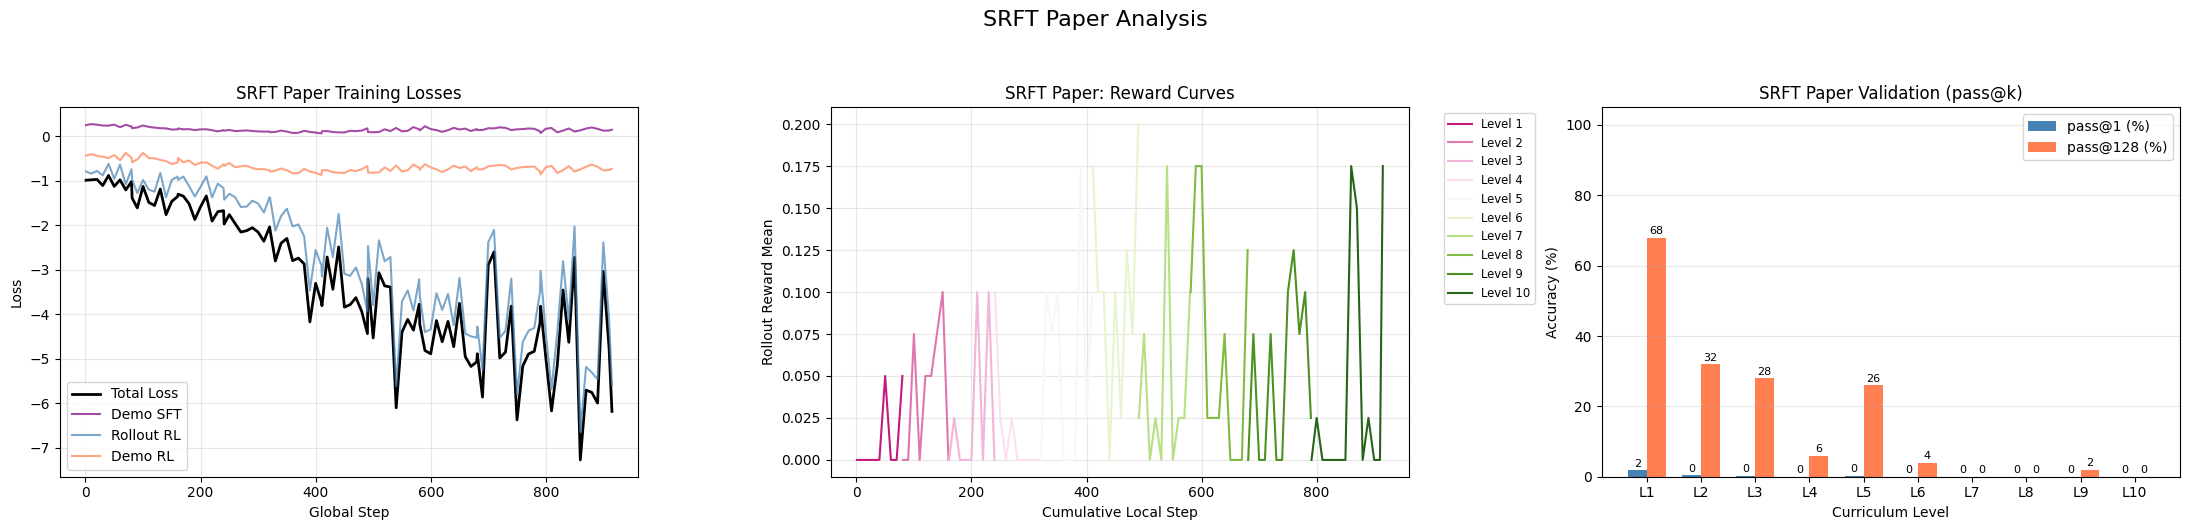

SRFT выглядит нестабильно: на лёгких уровнях ещё встречаются попадания среди многих сэмплов, но one-shot качество почти не формируется.

### Сравнение методов по pass@128

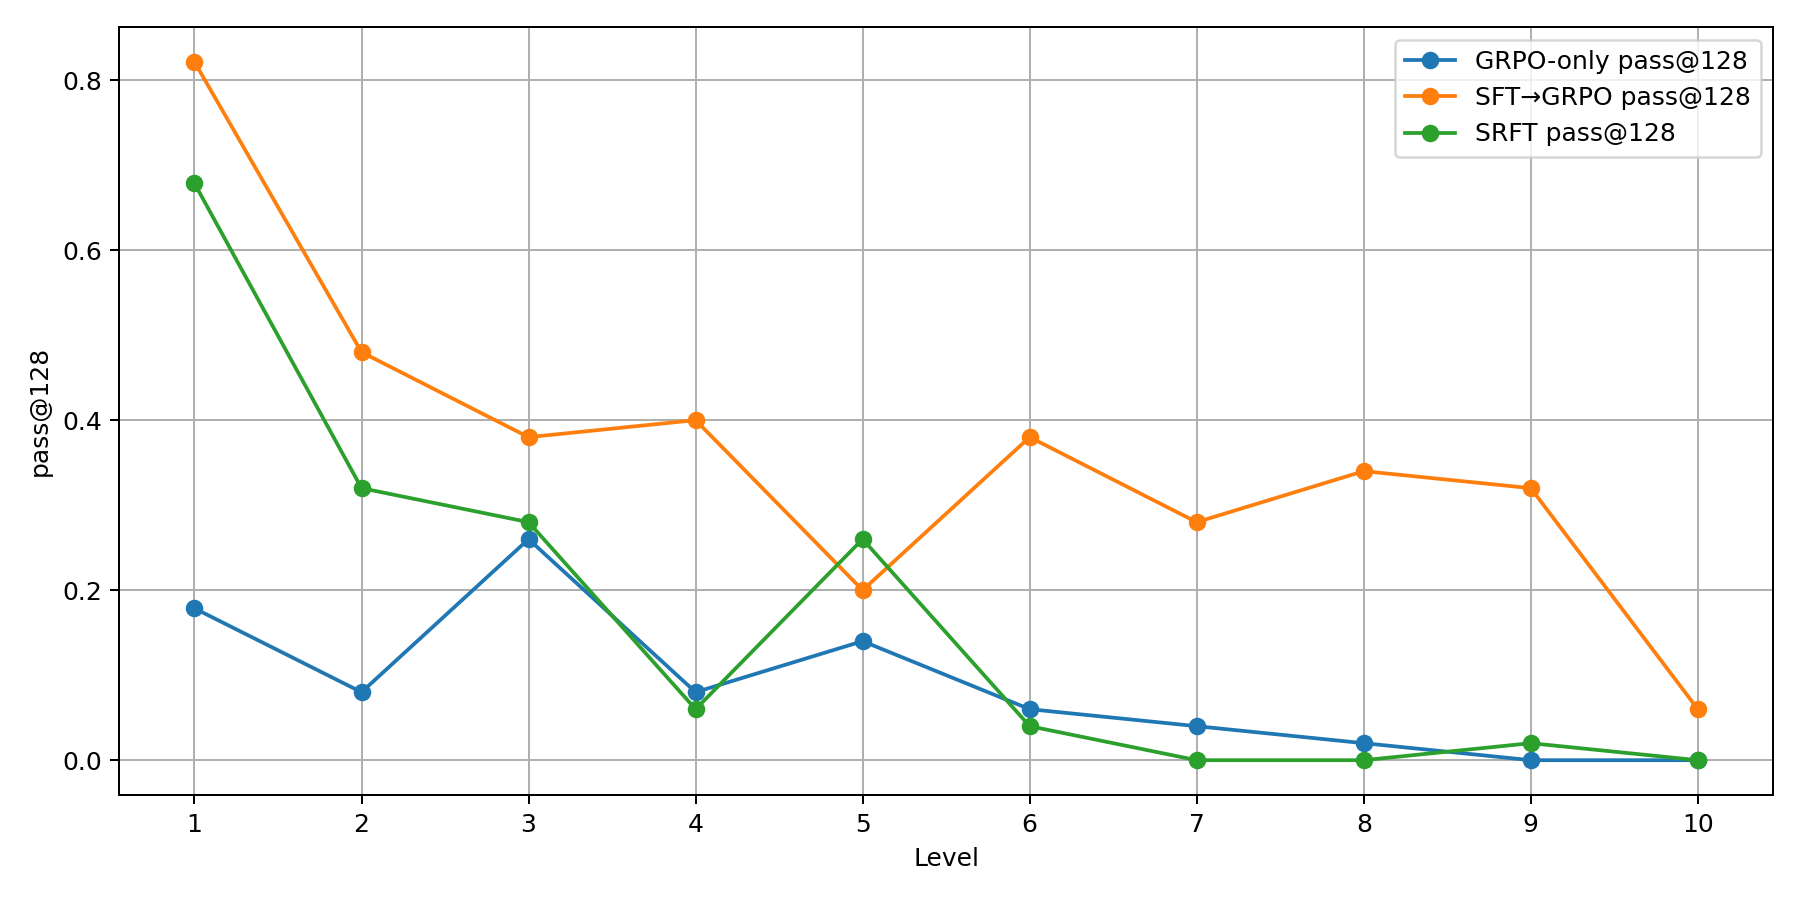

По `pass@128` почти везде выигрывает **SFT→GRPO**. У SRFT есть отдельные всплески, но устойчивого преимущества не видно.

### Сравнение методов по pass@1

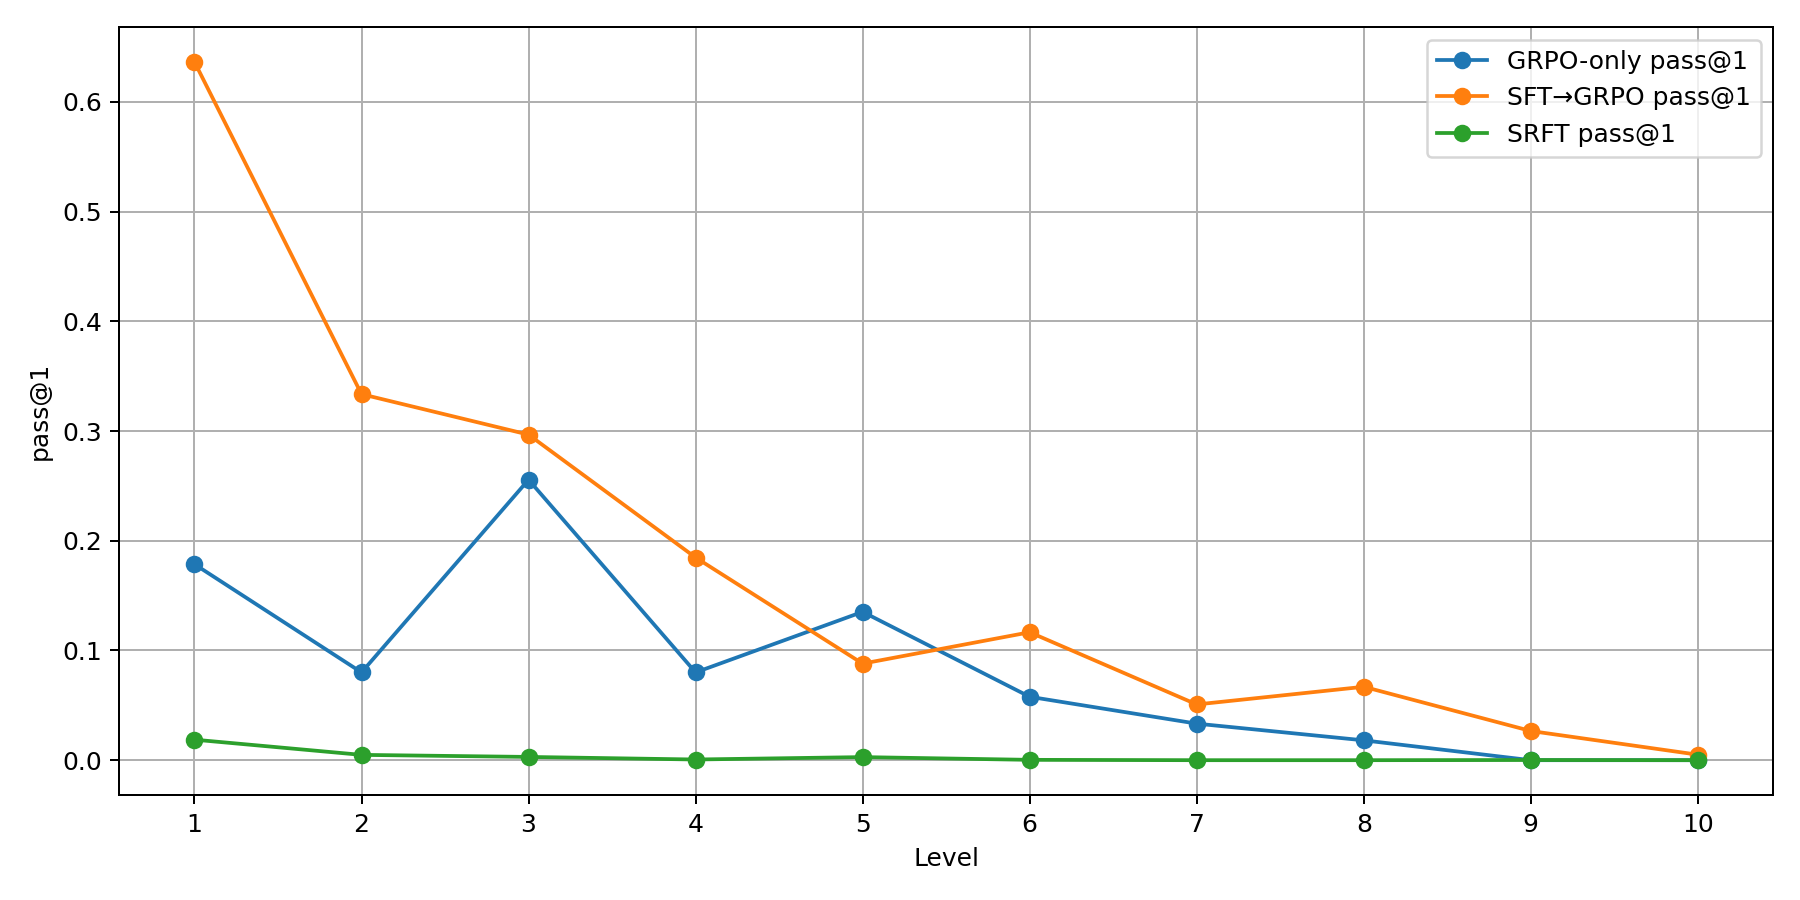

По `pass@1` картина ещё жёстче: **SFT→GRPO** лучший почти на всех уровнях, а у SRFT показатели почти нулевые.

## 5. Основные выводы по методам

### 5.1. GRPO-only

GRPO-only действительно учится на части задач, особенно на простых и средних уровнях. Это видно по reward curves: с ростом уровня reward в среднем увеличивается, но итоговая обобщающая способность остаётся слабой.

Что важно:

- средний `pass@1 = 0.0839`
- средний `pass@128 = 0.0859`
- почти везде `pass@1 ≈ pass@128`

Это означает, что политика у GRPO-only довольно “жёсткая”: если задача выучена, модель обычно решает её сразу; если не выучена, то 128 сэмплов почти не помогают. По сути, метод либо знает паттерн, либо не знает.

Сильная сторона GRPO-only — он может без демонстраций научиться некоторым шаблонам даже на уровнях с несколькими числами и скобками.  
Слабая сторона — **очень плохой перенос на сложные уровни**: на `L9` и `L10` качество уже нулевое.

### 5.2. SFT→GRPO

Это лучший метод в эксперименте.

По `pass@128` он лучший на 9 из 10 уровней, а на сложных уровнях превосходит остальные методы с большим запасом:

- `L8`: `0.3400` против `0.0200` у GRPO-only и `0.0000` у SRFT
- `L9`: `0.3200` против `0.0000` у GRPO-only и `0.0200` у SRFT
- `L10`: `0.0600` против `0.0000` у GRPO-only и `0.0000` у SRFT

По `pass@1` SFT→GRPO тоже почти везде лучший; исключение — `L5`, где GRPO-only немного выше (`0.1352` против `0.0880`).

Интерпретация простая: **демонстрации дают хорошую стартовую политику**, а последующий GRPO дооптимизирует её под reward. Это особенно важно для сложных уровней, где “с нуля” выйти на корректный синтаксис и правильный ответ очень трудно.

### 5.3. SRFT

SRFT получился самым странным и самым интересным результатом.

С одной стороны, у него не совсем нулевой `pass@128` на лёгких уровнях:

- `L1`: `0.6786`
- `L2`: `0.3200`
- `L3`: `0.2800`
- `L5`: `0.2600`

Более того, на `L5` по `pass@128` SRFT даже обгоняет SFT→GRPO (`0.2600` против `0.2000`).

Но по `pass@1` ситуация катастрофическая:

- `L1`: `0.0187`
- `L2`: `0.0048`
- `L3`: `0.0030`
- `L5`: `0.0028`

То есть SRFT **иногда случайно находит** правильное решение среди 128 сэмплов, но политика не становится устойчивой.  
Это особенно видно по огромному разрыву между `pass@1` и `pass@128`.

Практический вывод: в текущей реализации SRFT не научил модель уверенно решать задачи в one-shot режиме.


## 6. Почему SRFT, скорее всего, провалился

### 6.1. В логах SRFT нет положительных rollout’ов

Это самый сильный диагностический сигнал из всего ноутбука.

Из логов обучения SRFT:

- demo records: **19448**
- всего распарсено **102** логируемых шага
- на всех логируемых шагах: `pos=0`, `neg=2`

Иначе говоря, self-rollout часть обучения **ни разу не получила положительный on-policy пример**.  
Это очень похоже на главную причину провала. Вместо схемы “усиливаем хорошие self-generated решения и ослабляем плохие” обучение фактически превращается в:

- слабый supervised сигнал от demonstrations
- плюс штрафование отрицательных rollout’ов

В таком режиме модель не получает достаточного сигнала, чтобы построить сильную политику.

### 6.2. Слишком мало rollouts для single-stage self-improvement

В конфиге SRFT:

- `num_generations = 2`
- `rollout_batch_size = 1`
- `max_completion_length = 96`

Для модели размера `0.5B` это очень жёсткий режим. Вероятность случайно сгенерировать **полностью корректное** выражение слишком мала, особенно когда positive определяется exact-correctness.

То, что `pos=0` наблюдается на всех логируемых шагах, согласуется с этой гипотезой.

### 6.3. Демонстрационная часть слишком слабая, чтобы компенсировать отсутствие positive rollouts

Хотя demo-датасет большой (`19448` записей), в SRFT на каждом шаге используется только `demo_batch_size=2`.  
Всего шагов порядка `915`, так что модель видит сравнительно небольшой supervised сигнал без полноценного warmup, который был у SFT→GRPO.

Поэтому:

- **SFT→GRPO** сначала действительно получает сильную инициализацию
- **SRFT** пытается учиться “всё сразу”, но on-policy часть не стартует

### 6.4. Как это аккуратно сформулировать в отчёте

По коду видно, что это не буквальная реплика paper setup, а адаптированная SRFT-подобная схема. Для отчёта лучше писать так:

> Мы реализовали упрощённую SRFT-подобную single-stage схему, а не точную репликацию исходного experimental setup.

Это защищает отчёт от слишком сильного утверждения вида “SRFT по статье хуже”, потому что по факту здесь сравнивается **твоя реализация SRFT в конкретном режиме**, а не полный faithful reproduction.


## 7. Репрезентативные примеры из ноутбука

### 7.1. Примеры задач, которые GRPO-only уверенно решал

Ниже — примеры, которые в диагностике GRPO-only были отмечены как “уверенно решённые”:

- `nums=['4', '4'] target=0 gold=4 - 4  [128/128]`
- `nums=['9', '6', '5'] target=8 gold=9 - (6 - 5)  [128/128]`
- `nums=['7', '3', '2', '7'] target=13 gold=(7 - (3 - 2)) + 7  [128/128]`
- `nums=['81', '77', '36', '70', '80'] target=118 gold=81 - (77 + (36 - (70 + 80)))  [85/128]`

Это показывает, что GRPO-only способен выучивать не только тривиальные вычитания, но и выражения со скобками и вложенными операциями.

### 7.2. Репрезентативные нерешённые задачи для GRPO-only

- `nums=['7', '4'] target=28 gold=7 * 4`
- `nums=['9', '4', '1', '7'] target=42 gold=(9 * 4) - (1 - 7)`
- `nums=['89', '69', '78', '59', '93', '8', '85'] target=21 gold=((89 + (69 - (78 + 59))) * 93) / (8 + 85)`

Здесь заметно, что GRPO-only проваливается уже на простых мультипликативных или композиционных примерах, а на L10 полностью теряет обобщение.

### 7.3. Репрезентативные нерешённые задачи для SFT→GRPO

- `#9: numbers=['5', '3'] target=15 gold=5 * 3`
- `#0: numbers=['9', '4', '1', '7'] target=42 gold=(9 * 4) - (1 - 7)`
- `#1: numbers=['30', '39', '27', '98', '21', '11', '4'] target=31478 gold=(30 * (39 * 27)) - ((98 + 21) - (11 - 4))`

Даже у лучшего метода остаются ошибки. Интересно, что среди нерешённых на `L1` есть довольно простые примеры на умножение. Это может указывать не только на содержательную ошибку, но и на влияние sampling, exact verification и форматных ограничений.

### 7.4. Репрезентативные нерешённые задачи для SRFT

- `#5: numbers=['7', '4'] target=28 gold=7 * 4`
- `#1: numbers=['1', '5', '9', '3'] target=17 gold=1 * 5 + 9 + 3`
- `#0: numbers=['89', '29', '48', '67', '59'] target=66 gold=(89 - 29) + (48 / (67 - 59))`

SRFT теряет качество уже на лёгких уровнях в смысле one-shot поведения, а начиная с `L7` фактически перестаёт решать задачи.


## 8. Интерпретация результатов для текста отчёта

Если писать вывод коротко и по делу, его можно сформулировать так:

> В эксперименте на Target24 наилучшие результаты показал подход SFT→GRPO. Это указывает на то, что для данной задачи качество начальной политики критично: supervised fine-tuning на gold trajectories задаёт рабочий шаблон решения, после чего reward-based дообучение действительно улучшает поведение модели.  
>  
> GRPO-only способен обучаться на части простых и средних уровней, но практически не переносится на сложные.  
>  
> SRFT в текущей реализации дал смешанный результат: по `pass@128` он иногда находит корректные решения на лёгких уровнях и даже выигрывает у SFT→GRPO на `L5`, однако по `pass@1` показывает почти нулевое качество. Анализ логов показывает, что self-rollout часть обучения не производила положительных on-policy примеров (`pos=0` на всех логируемых шагах), поэтому single-stage SRFT фактически не получал ключевого сигнала для self-improvement. Следовательно, слабый результат SRFT здесь, вероятнее всего, объясняется не самой идеей метода, а конкретным training regime и реализацией.


## 9. Что бы я рекомендовала сделать дальше

1. Для честной перепроверки SRFT увеличить `num_generations` хотя бы до `8`.
2. Ослабить bottleneck по rollout’ам: увеличить `rollout_batch_size` и/или `max_completion_length`.
3. Добавить явный мониторинг positive rate как основной диагностический показатель.
4. Либо сделать короткий SFT warmup перед SRFT, либо усилить demo-часть single-stage обучения.
5. Если важен faithful reproduction paper, аккуратно сблизить objective и training recipe с оригиналом.

---

### Приложение

- Внутри ноутбука графики уже встроены, поэтому он открывается как самостоятельный отчёт.
- Таблица метрик также сохранена отдельно как `metrics_by_level.csv`.
